In [4]:
import warnings
warnings.filterwarnings('ignore')
import os as os
os.chdir('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/')
%matplotlib inline
from WildAlertpy import WRMDalert as alert
from WildAlertpy import read_data as read_data
from WildAlertpy import anomaly as an
data_path = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/wildalert exports/'
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.style as style
import numpy as np
import math
#style.use('fivethirtyeight')
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_context("notebook", font_scale=1.30, rc={"lines.linewidth": 0.8})

In [5]:
HPAI = pd.read_csv('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/HPAI Detections in Wild Birds.csv')
HPAI.head()

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency
0,New York,Erie,6/23/2025,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC
1,New York,Erie,6/23/2025,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC
2,New York,Erie,6/23/2025,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC
3,Missouri,Barry,6/23/2025,7/15/2025,EA H5N1,Bald eagle,Wild bird,Morbidity/Mortality,MO Dept of Conservation
4,Florida,Hillsborough,3/20/2025,7/3/2025,EA/AM H5N1,Bald eagle,Wild bird,Morbidity/Mortality,Private (non-government) submission


Ibis = shorebird
Egret = shorebird
Cormorant = marinebird
Common =marinebird
Common loon = marinebird

In [6]:
species_group_dict = {
    # Raptors
    'Caspian tern': 'Marine birds',
    'Bald eagle': 'Raptors',
    'Black vulture': 'Raptors',
    'Peregrine falcon': 'Raptors',
    'Red-tailed hawk': 'Raptors',
    'Red-shouldered hawk': 'Raptors',
    'Great horned owl': 'Raptors',
    "Cooper's hawk": 'Raptors',
    'Turkey vulture': 'Raptors',
    'Barn owl': 'Raptors',
    'Barred owl': 'Raptors',
    'Broad-winged hawk': 'Raptors',
    'Golden eagle': 'Raptors',
    'Osprey': 'Raptors',
    'Northern harrier': 'Raptors',
    'Short-eared owl': 'Raptors',
    'Crested caracara': 'Raptors',
    'Sharp-shinned hawk': 'Raptors',
    "Swainson's hawk": 'Raptors',
    'Ferruginous hawk': 'Raptors',
    'California condor': 'Raptors',
    'Eastern screech owl': 'Raptors',
    'Western screech owl': 'Raptors',
    'Long-eared owl': 'Raptors',
    'Prairie falcon': 'Raptors',
    'Harris hawk': 'Raptors',
    'Rough-legged hawk': 'Raptors',
    'Eagle (unidentified)': 'Raptors',
    'Owl (unidentified)': 'Raptors',
    
    # Waterbirds
    'Goose (unidentified)': 'Waterbirds',
    'Canada goose': 'Waterbirds',
    'Snow goose': 'Waterbirds',
    'Cackling goose': 'Waterbirds',
    'Hooded merganser': 'Waterbirds',
    'Mallard': 'Waterbirds',
    'Trumpeter swan': 'Waterbirds',
    'Common eider': 'Waterbirds',
    'American wigeon': 'Waterbirds',
    'Pied-billed grebe': 'Waterbirds',
    'Bufflehead': 'Waterbirds',
    'Ring-necked duck': 'Waterbirds',
    'Eared grebe': 'Waterbirds',
    'Duck (unidentified)': 'Waterbirds',
    'Gadwall': 'Waterbirds',
    'Wood duck': 'Waterbirds',
    'Green-winged teal': 'Waterbirds',
    'Northern shoveler': 'Waterbirds',
    'Surf scoter': 'Waterbirds',
    'White-winged scoter': 'Waterbirds',
    'Common loon': 'Marine birds',
    'Tundra swan': 'Waterbirds',
    'Blue-winged teal': 'Waterbirds',
    'Northern pintail': 'Waterbirds',
    'American black duck': 'Waterbirds',
    'Mallard/Black duck hybrid': 'Waterbirds',
    'Ruddy duck': 'Waterbirds',
    'Greater scaup': 'Waterbirds',
    'Wild hybrid duck (Anatidae)': 'Waterbirds',
    'Merganser (unidentified)': 'Waterbirds',
    'Canvasback': 'Waterbirds',
    'Teal (unidentified)': 'Waterbirds',
    'Common goldeneye': 'Waterbirds',
    'Horned grebe': 'Marine birds',
    'Redhead duck': 'Waterbirds',
    'Common merganser': 'Waterbirds',
    'Ring-Necked Duck': 'Waterbirds',
    'Ruddy Duck': 'Waterbirds',
    'Ring necked duck': 'Waterbirds',
    'Muscovy duck': 'Waterbirds',
    'Mottled duck': 'Waterbirds',
    'Snowy egret': 'Shorebirds',
    'Great egret': 'Shorebirds',
    'Cattle egret': 'Shorebirds',
    'White-faced ibis': 'Shorebirds',
    'Glossy ibis': 'Shorebirds',
    'American coot': 'Waterbirds',
    'Fulvous whistling duck': 'Waterbirds',
    'Black-bellied whistling duck': 'Waterbirds',
    'Mute swan': 'Waterbirds',
    'Brant': 'Waterbirds',
    'Double-crested cormorant': 'Waterbirds',
    'Northen pintail': 'Waterbirds',
    'Black-neck swan': 'Waterbirds',
    'Black swan': 'Waterbirds',
    'Red-necked grebe': 'Marine birds',
    'Western grebe': 'Marine birds',
    'Pacific loon': 'Marine birds',
    'Black-crowned night heron': 'Waterbirds',
    'Cormorant (unidentified)': 'Waterbirds',
    'Green heron': 'Shorebirds',
    'American wood stork': 'Waterbirds',
    'Eider (unidentified)': 'Waterbirds',
    'Heron (unidentified)': 'Waterbirds',
    'Neotropic cormorant': 'Waterbirds',
    'Swan (unidentified)': 'Waterbirds',

    # Marine birds
    'Herring gull': 'Marine birds',
    "Bonaparte's gull": 'Marine birds',
    'Glaucous gull': 'Marine birds',
    'Glaucous-winged gull': 'Marine birds',
    'California gull': 'Marine birds',
    'Ring-billed gull': 'Marine birds',
    'Royal tern': 'Marine birds',
    'Gull (unidentified)': 'Marine birds',
    'Great black-backed gull': 'Marine birds',
    'Laughing gull': 'Marine birds',
    'Black skimmer': 'Marine birds',
    'Black turnstone': 'Marine birds',
    "Sabine's gull": 'Marine birds',
    "Thayer's gull": 'Marine birds',
    'Short-billed gull': 'Marine birds',
    'Arctic tern': 'Marine birds',
    'Parasitic jaeger': 'Marine birds',
    'Sandwich tern': 'Marine birds',
    'Common tern': 'Marine birds',
    'Forster\'s tern': 'Marine birds',
    'Black-legged kittiwake': 'Marine birds',
    'Common murre': 'Marine birds',
    'Short-tailed shearwater': 'Marine birds',

    # Songbirds
    'Song sparrow': 'Songbirds',
    'House sparrow': 'Songbirds',
    'Great-tailed Grackle': 'Songbirds',
    'Great-tailed grackle': 'Songbirds',
    'Fish crow': 'Songbirds',
    'European starling': 'Songbirds',
    'Common grackle': 'Songbirds',
    'Blue jay': 'Songbirds',
    'House finch': 'Songbirds',
    "Say's phoebe": 'Songbirds',
    "Brewer's blackbird": 'Songbirds',
    "Lincoln's sparrow": 'Songbirds',
    'Savannah sparrow': 'Songbirds',
    'White-crowned sparrow': 'Songbirds',
    'Crow (unidentified)': 'Songbirds',
    'Blackbird (unidentified)': 'Songbirds',
    'Plush-crested jay': 'Songbirds',
    'Tree swallow': 'Songbirds',
    'Dark-eyed junco': 'Songbirds',
    'Lark bunting': 'Songbirds',
    'Lark sparrow': 'Songbirds',
    'American robin': 'Songbirds',
    'Red-winged blackbird': 'Songbirds',
    'Barn swallow': 'Songbirds',
    'Summer tanager': 'Songbirds',
    'Finch (unidentified)': 'Songbirds',
    'Warbler (unidentified)': 'Songbirds',
    'Boat-tailed grackle': 'Songbirds',
    'Swallow (unidentified)': 'Songbirds',
    'Grackle (unidentified)': 'Songbirds',
    'Magpie (unidentified)': 'Songbirds',

    # Shorebirds
    'Sandhill crane': 'Shorebirds',
    'Sanderling': 'Shorebirds',
    'Dunlin': 'Shorebirds',
    'Western sandpiper': 'Shorebirds',
    'American woodcock': 'Shorebirds',
    'Black-necked stilt': 'Shorebirds',
    'Snowy plover': 'Shorebirds',
    'Red-necked phalarope': 'Shorebirds',
    'Willet': 'Shorebirds',
    'Greater sage grouse': 'Shorebirds',
    'Ruffed grouse': 'Shorebirds',
    'Ring-necked pheasant': 'Shorebirds',
    'Pheasant (unidentified)': 'Shorebirds',
    'California quail': 'Shorebirds',
    "Gambel's quail": 'Shorebirds',

    # Other birds
    'Rock pigeon': 'Other birds',
    'Mourning Dove': 'Other birds',
    'Mourning dove': 'Other birds',
    'White-winged dove': 'Other birds',
    'Pigeon (unidentified)': 'Other birds',

    # Exotic birds
    'Flamingo (unidentified)': 'Exotic birds',
    'Chilean flamingo': 'Exotic birds',
    'Peafowl (unidentified)': 'Exotic birds',
    'Greater rhea': 'Exotic birds',
    'Rhea (unidentified)': 'Exotic birds',
    'Emu': 'Exotic birds',
    'African crowned crane': 'Exotic birds',
    'Crested screamer': 'Exotic birds',
    'Crane (unidentified)': 'Exotic birds',
    'Lorikeet (unidentified)': 'Exotic birds',
    'Kookaburra (unidentified)': 'Exotic birds',
    'Dalmatian pelican': 'Exotic birds',
    'Scarlet ibis': 'Exotic birds',
    'Egyptian goose': 'Exotic birds',
    'Scaly-sided merganser': 'Exotic birds',
    'Smew': 'Exotic birds',
    "Baer's pochard": 'Exotic birds',
    'Puna teal': 'Exotic birds',
    'Brazilian teal': 'Exotic birds',
    'King vulture': 'Exotic birds',
}


In [7]:
# Map to new column
# Apply species group mapping
HPAI['Bird Group'] = HPAI['Bird Species'].map(species_group_dict).fillna('Unknown')
# Extract week from collection date
# Convert to datetime first
HPAI['Collection Date'] = pd.to_datetime(HPAI['Collection Date'], errors='coerce')
# Drop rows where date conversion failed (optional but helps avoid downstream errors)
HPAI = HPAI.dropna(subset=['Collection Date'])


In [8]:
HPAI.head()

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency,Bird Group
0,New York,Erie,2025-06-23,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC,Marine birds
1,New York,Erie,2025-06-23,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC,Marine birds
2,New York,Erie,2025-06-23,7/15/2025,EA/AM H5N1,Caspian tern,Wild bird,Morbidity/Mortality,NY DEC,Marine birds
3,Missouri,Barry,2025-06-23,7/15/2025,EA H5N1,Bald eagle,Wild bird,Morbidity/Mortality,MO Dept of Conservation,Raptors
4,Florida,Hillsborough,2025-03-20,7/3/2025,EA/AM H5N1,Bald eagle,Wild bird,Morbidity/Mortality,Private (non-government) submission,Raptors


In [9]:
HPAI['Bird Group'].value_counts()

Bird Group
Waterbirds      9050
Raptors         2636
Unknown          866
Marine birds     346
Songbirds        266
Shorebirds       149
Other birds       96
Exotic birds      29
Name: count, dtype: int64

In [10]:
def get_weekly_counts_by_group(df, group_name):
    """
    For a given bird group, return a dictionary of DataFrames keyed by state.
    Each DataFrame contains weekly counts of observations based on 'Collection Date'.
    
    Parameters:
    - df: pandas DataFrame with at least ['Bird Group', 'State', 'Collection Date'] columns
    - group_name: string, name of the bird group to filter by
    
    Returns:
    - dict: { state_name: DataFrame with columns ['Week', 'Count'] }
    """
    
    # Filter by bird group
    df_group = df[df['Bird Group'] == group_name].copy()
    
    # Check that 'Collection Date' is datetime, else convert
    if not pd.api.types.is_datetime64_any_dtype(df_group['Collection Date']):
        df_group['Collection Date'] = pd.to_datetime(df_group['Collection Date'], errors='coerce')
    
    # Drop rows with missing dates
    df_group = df_group.dropna(subset=['Collection Date'])
    
    # Create a 'Week' column (week start date)
    df_group['Week'] = df_group['Collection Date'].dt.to_period('W').apply(lambda r: r.start_time)
    
    # Dictionary to hold results per state
    weekly_counts_by_state = {}
    
    # Loop over each unique state in this group
    for state in df_group['State'].unique():
        df_state = df_group[df_group['State'] == state]
        weekly_counts = (
            df_state.groupby('Week')
            .size()
            .reset_index(name='Count')
            .sort_values('Week')
            .reset_index(drop=True)
        )
        weekly_counts_by_state[state] = weekly_counts
    
    return weekly_counts_by_state


In [11]:
#get_weekly_counts_by_group(df = HPAI,group_name='Marine birds')

In [12]:
def plot_weekly_timelines_for_group(df, group_name, save_path=None):
    """
    Plot weekly observation timelines for each state within a bird group,
    filling missing weeks with zeroes between first and last detection.
    """
    weekly_counts_by_state = get_weekly_counts_by_group(df, group_name)
    states = list(weekly_counts_by_state.keys())
    n_states = len(states)
    
    # Layout for subplots (4 per row)
    ncols = 4
    nrows = math.ceil(n_states / ncols)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 4 * nrows), sharex=False, sharey=False)
    fig.suptitle(f"Weekly Detections of {group_name} by State", fontsize=16)
    
    axes = axes.flatten()
    
    for idx, state in enumerate(states):
        ax = axes[idx]
        data = weekly_counts_by_state[state].copy()
        
        # Ensure 'Week' is datetime
        data['Week'] = pd.to_datetime(data['Week'])

        # Create complete weekly timeline
        full_range = pd.date_range(start=data['Week'].min(), end=data['Week'].max(), freq='W-MON')
        full_df = pd.DataFrame({'Week': full_range})
        
        # Merge and fill missing with 0
        merged = pd.merge(full_df, data, on='Week', how='left').fillna(0)
        merged['Count'] = merged['Count'].astype(int)
        
        # Plot
        sns.lineplot(data=merged, x='Week', y='Count', ax=ax, marker='o')
        #sns.barplot(data=merged, x='Week', y='Count', ax=ax)
        #ax.bar(merged['Week'], merged['Count'], width=5, align='center', color='steelblue')
        ax.set_title(state)
        ax.set_xlabel("")
        ax.set_ylabel("Observations")
        ax.tick_params(axis='x', rotation=45)
    
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

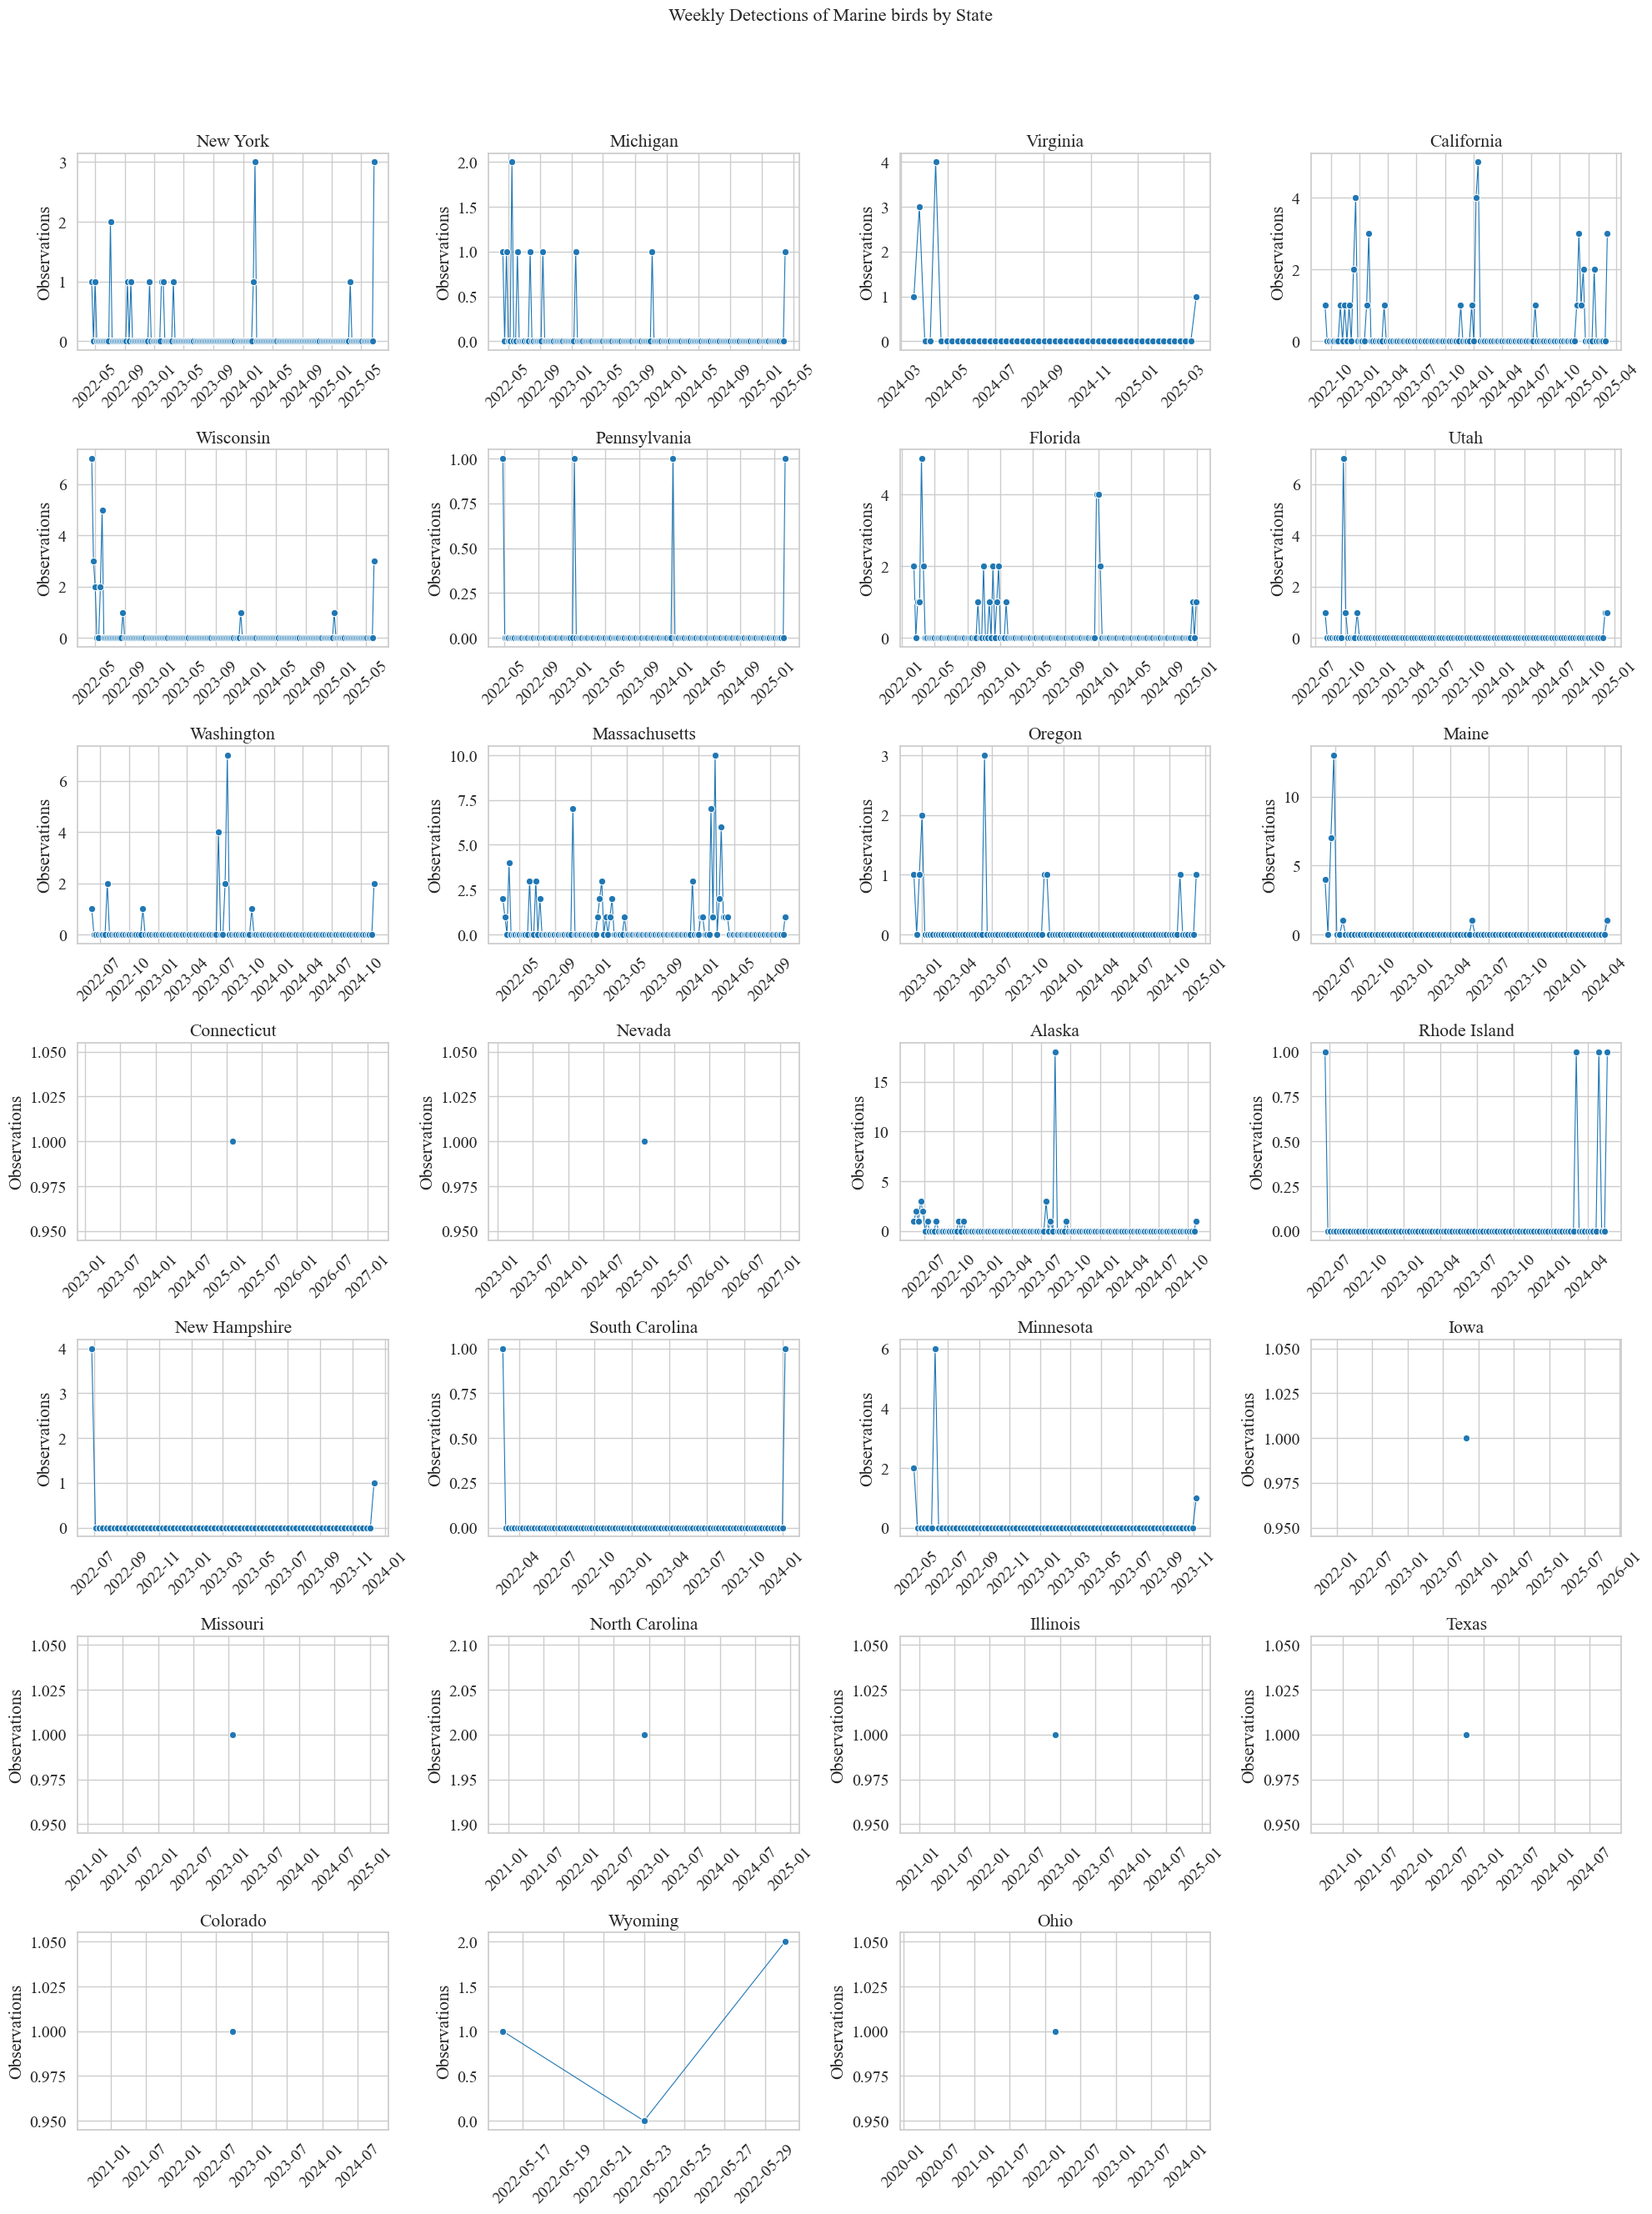

CPU times: total: 27.4 s
Wall time: 30 s


In [10]:
%%time
plot_weekly_timelines_for_group(df = HPAI,group_name='Marine birds')

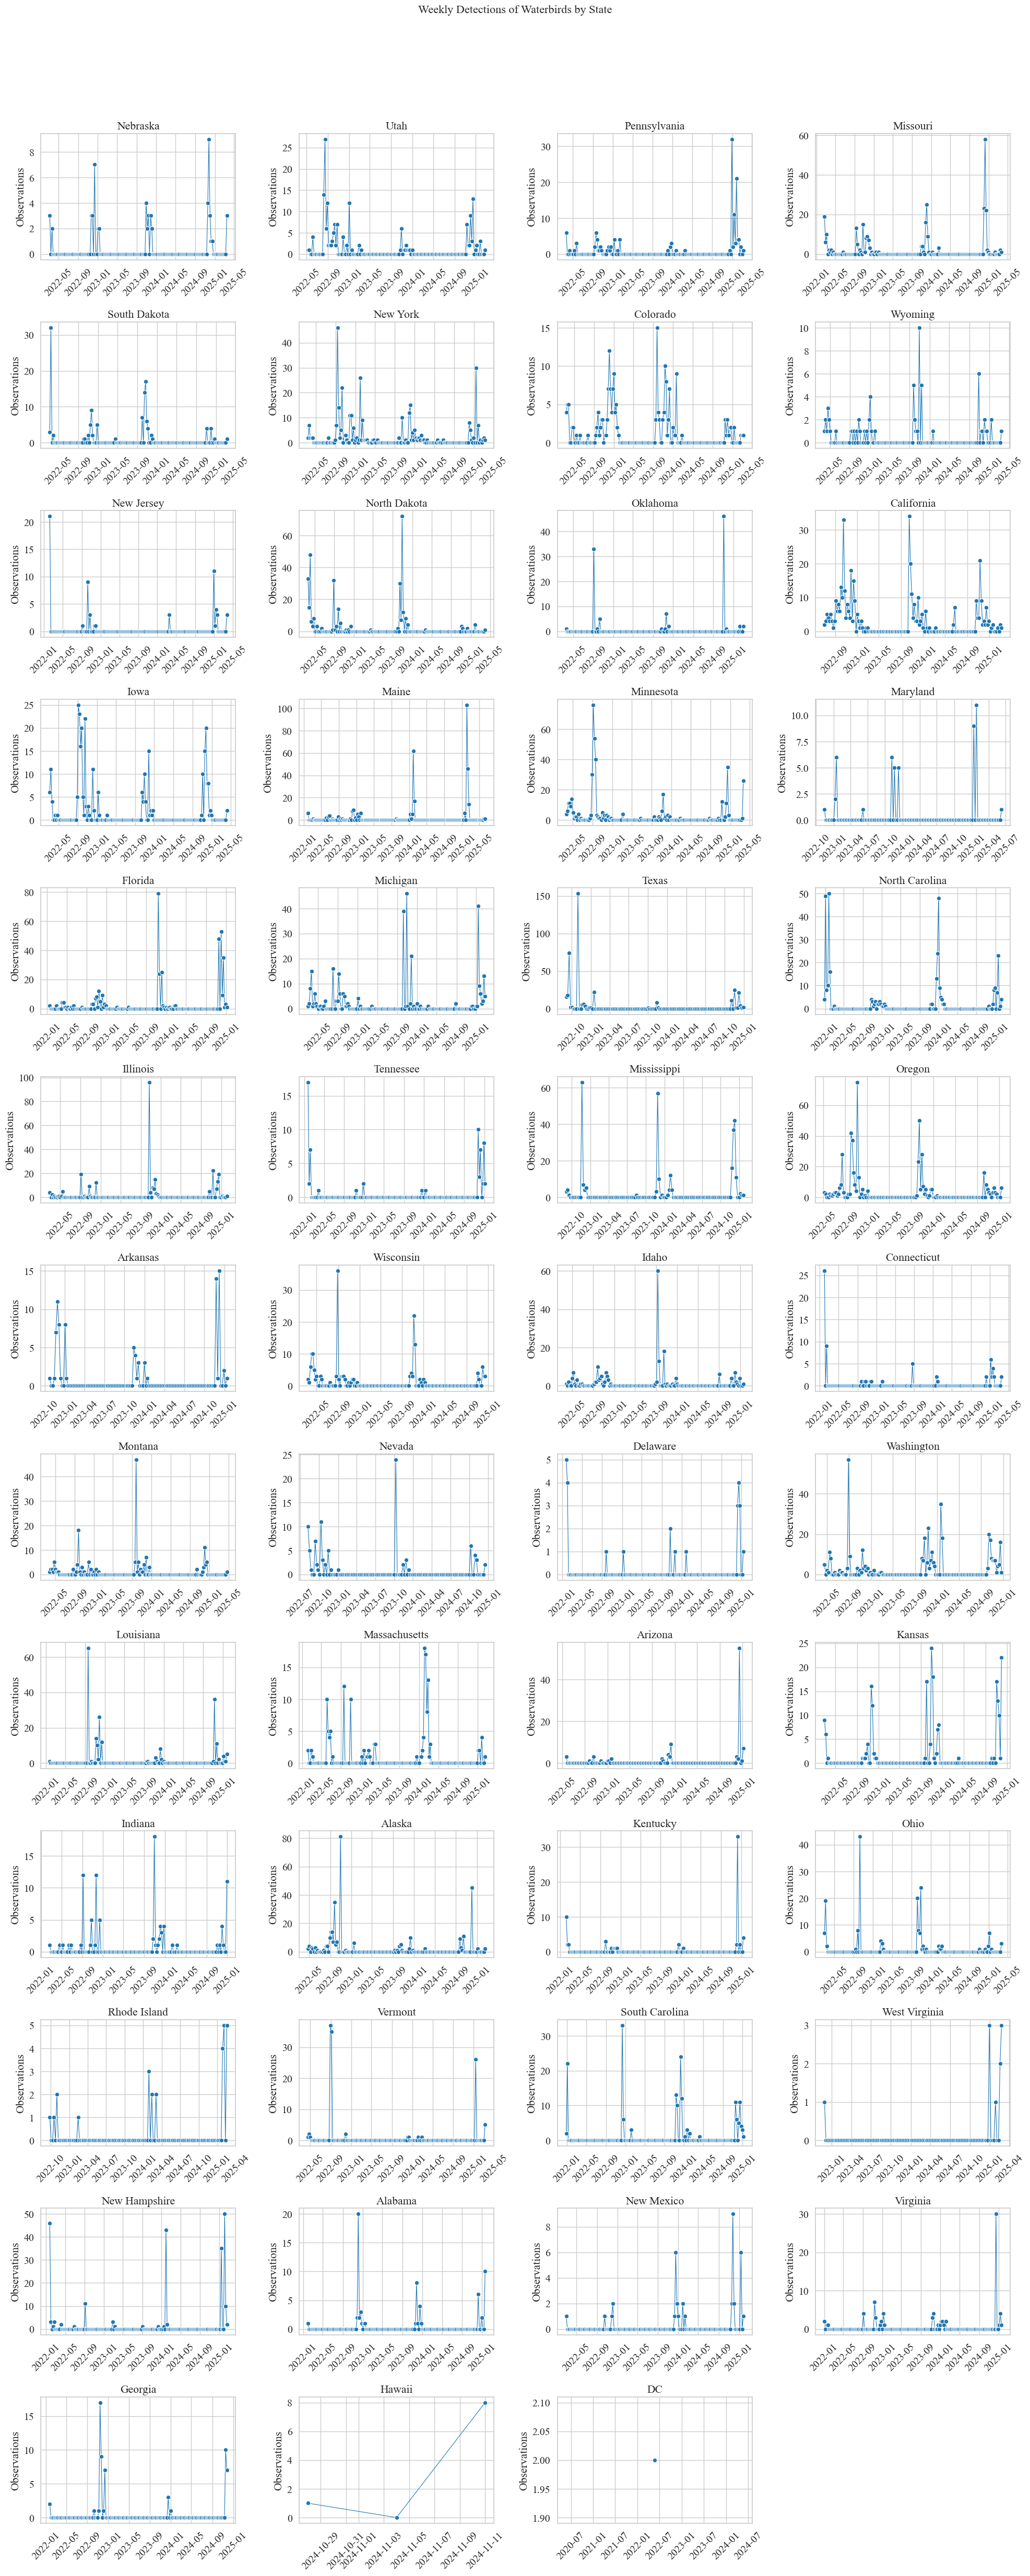

CPU times: total: 53.5 s
Wall time: 59.3 s


In [11]:
%%time
plot_weekly_timelines_for_group(df = HPAI,group_name='Waterbirds')

In [12]:
# Prepare once


In [13]:
def get_consecutive_periods_all_groups(df):
    """
    For each group and each state, find periods of consecutive months
    with detections and return a pivoted summary DataFrame.
    
    Returns:
        A DataFrame where rows = states, columns = bird groups,
        and values = list of (start, end, duration_days) tuples.
    """
    df = df.copy()
    df['Collection Date'] = pd.to_datetime(df['Collection Date'])
    df['YearMonth'] = df['Collection Date'].dt.to_period('M')
    
    result_dict = {}

    for group_name in df['Bird Group'].unique():
        group_df = df[df['Bird Group'] == group_name]
        for state, state_group in group_df.groupby('State'):
            months = sorted(state_group['YearMonth'].unique())
            months = pd.Series(months).astype(str)
            month_dates = pd.to_datetime(months, format='%Y-%m')

            # Track sequences
            seqs = []
            if not month_dates.empty:
                seq_start = month_dates[0]
                prev = month_dates[0]

                for i in range(1, len(month_dates)):
                    curr = month_dates[i]
                    # FIXED comparison using .ordinal
                    if (curr.to_period('M').ordinal - prev.to_period('M').ordinal) > 1:
                        seq_end = prev + pd.offsets.MonthEnd(0)
                        duration = (seq_end - seq_start).days + 1
                        seqs.append((seq_start.date(), seq_end.date(), duration))
                        seq_start = curr
                    prev = curr

                # Final sequence
                seq_end = prev + pd.offsets.MonthEnd(0)
                duration = (seq_end - seq_start).days + 1
                seqs.append((seq_start.date(), seq_end.date(), duration))

            # Store
            if state not in result_dict:
                result_dict[state] = {}
            result_dict[state][group_name] = seqs

    # Convert to DataFrame
    summary_df = pd.DataFrame.from_dict(result_dict, orient='index').fillna('')

    # Optional: sort columns
    summary_df = summary_df[sorted(summary_df.columns)]
    
    return summary_df



def flatten_consecutive_periods(summary_df):
    """
    Flatten the nested summary_df into a long-form DataFrame.

    Returns:
        A DataFrame with columns: State, Group Name, Start Date, End Date, Duration (days)
    """
    records = []

    for state in summary_df.index:
        for group in summary_df.columns:
            periods = summary_df.at[state, group]
            if isinstance(periods, list):
                for start_date, end_date, duration in periods:
                    records.append({
                        'State': state,
                        'Group Name': group,
                        'Start Date': start_date,
                        'End Date': end_date,
                        'Duration (days)': duration
                    })

    flat_df = pd.DataFrame(records)
    return flat_df

In [14]:
group_summary_df = get_consecutive_periods_all_groups(HPAI)
flat_df = flatten_consecutive_periods(group_summary_df)
print(flat_df)

        State    Group Name  Start Date    End Date  Duration (days)
0      Alaska  Marine birds  2022-05-01  2022-08-31              123
1      Alaska  Marine birds  2022-10-01  2022-11-30               61
2      Alaska  Marine birds  2023-07-01  2023-09-30               92
3      Alaska  Marine birds  2024-10-01  2024-10-31               31
4      Alaska       Raptors  2022-04-01  2022-06-30               91
..        ...           ...         ...         ...              ...
835  Oklahoma    Waterbirds  2022-03-01  2022-03-31               31
836  Oklahoma    Waterbirds  2022-09-01  2022-10-31               61
837  Oklahoma    Waterbirds  2023-10-01  2023-12-31               92
838  Oklahoma    Waterbirds  2024-11-01  2024-11-30               30
839  Oklahoma    Waterbirds  2025-02-01  2025-03-31               59

[840 rows x 5 columns]


In [15]:
flat_df[(flat_df['Group Name'] == 'Raptors') & (flat_df['State'] == 'California')]

,State,Group Name,Start Date,End Date,Duration (days)
32,California,Raptors,2022-07-01,2023-04-30,304
33,California,Raptors,2023-07-01,2023-08-31,62
34,California,Raptors,2023-10-01,2024-04-30,213
35,California,Raptors,2024-11-01,2025-03-31,151


In [16]:
flat_df[(flat_df['Group Name'] == 'Raptors') & (flat_df['State'] == 'California')][['Start Date', 'End Date']].values

array([[datetime.date(2022, 7, 1), datetime.date(2023, 4, 30)],
       [datetime.date(2023, 7, 1), datetime.date(2023, 8, 31)],
       [datetime.date(2023, 10, 1), datetime.date(2024, 4, 30)],
       [datetime.date(2024, 11, 1), datetime.date(2025, 3, 31)]],
      dtype=object)

In [17]:
flat_df[(flat_df['Group Name'] == 'Raptors') & (flat_df['State'] == 'Florida')][['Start Date', 'End Date']].values

array([[datetime.date(2022, 1, 1), datetime.date(2023, 1, 31)],
       [datetime.date(2023, 3, 1), datetime.date(2023, 3, 31)],
       [datetime.date(2023, 11, 1), datetime.date(2024, 4, 30)],
       [datetime.date(2024, 6, 1), datetime.date(2025, 1, 31)],
       [datetime.date(2025, 3, 1), datetime.date(2025, 3, 31)]],
      dtype=object)

In [18]:
flat_df[(flat_df['Group Name'] == 'Waterbirds') & (flat_df['State'] == 'Florida')][['Start Date', 'End Date']].values

array([[datetime.date(2022, 1, 1), datetime.date(2022, 6, 30)],
       [datetime.date(2022, 8, 1), datetime.date(2022, 8, 31)],
       [datetime.date(2022, 10, 1), datetime.date(2022, 12, 31)],
       [datetime.date(2023, 3, 1), datetime.date(2023, 3, 31)],
       [datetime.date(2023, 5, 1), datetime.date(2023, 5, 31)],
       [datetime.date(2023, 11, 1), datetime.date(2024, 2, 29)],
       [datetime.date(2024, 11, 1), datetime.date(2025, 1, 31)]],
      dtype=object)

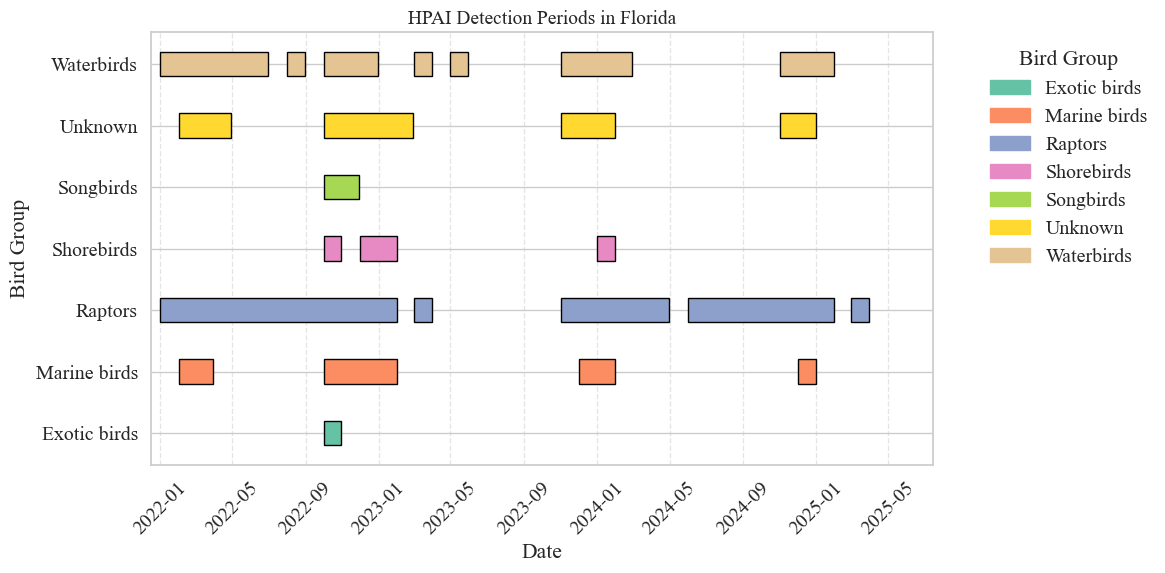

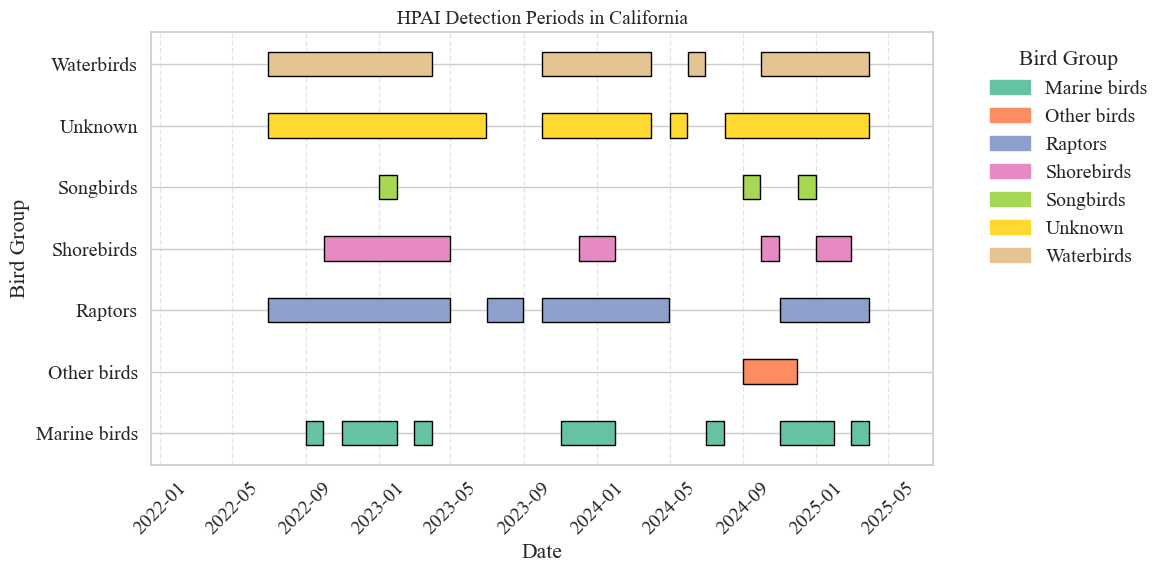

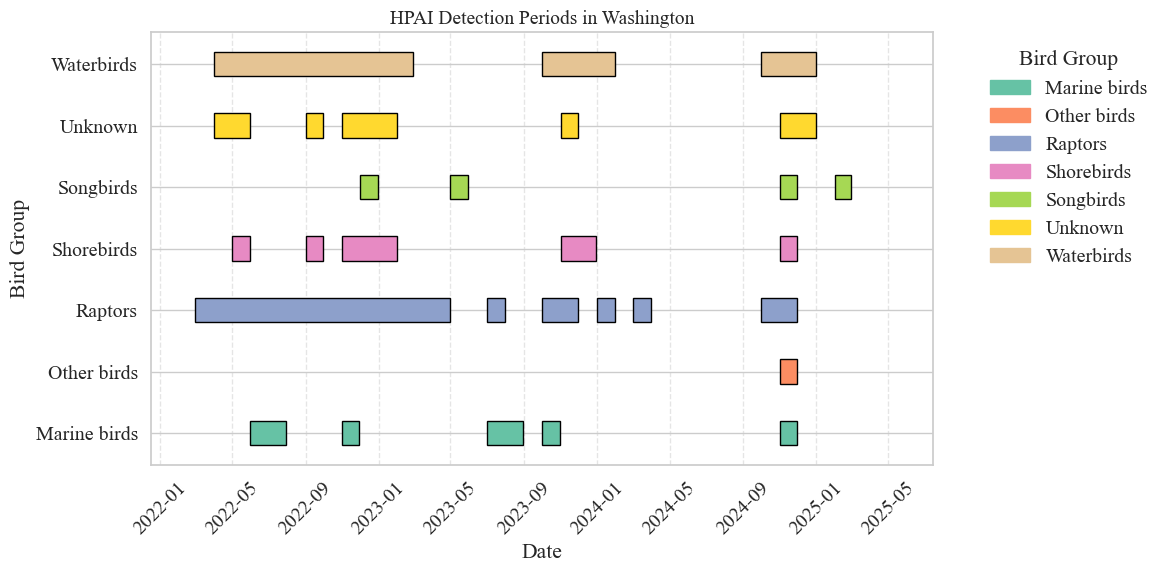

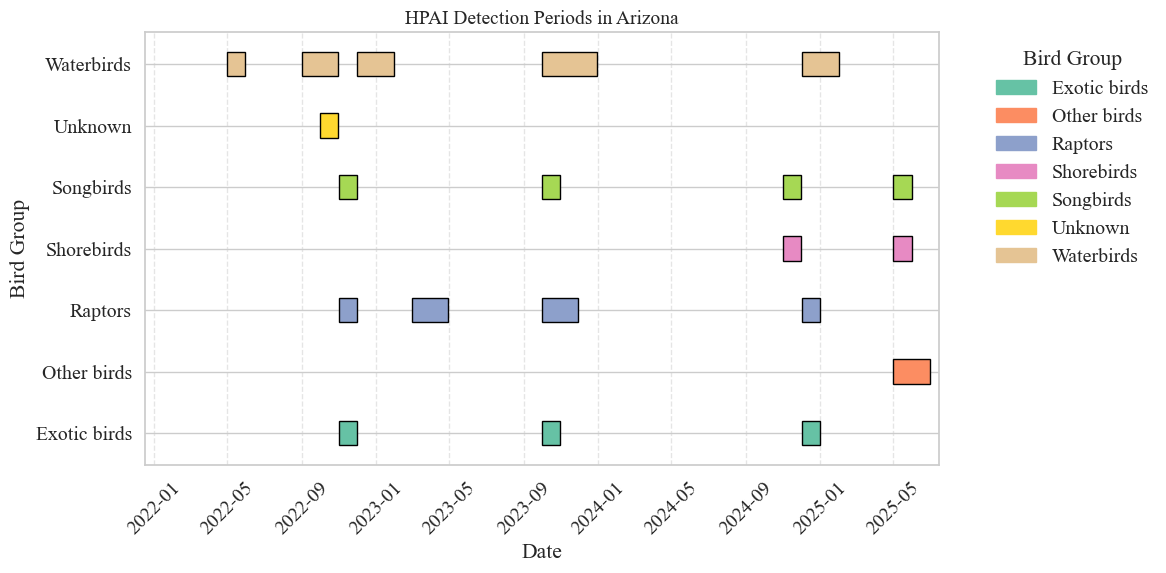

In [19]:
from matplotlib.patches import Patch
def plot_detection_timelines(df, states):
    """
    Plot horizontal bar timelines for each group in selected states.
    
    Args:
        df: DataFrame with columns ['State', 'Group Name', 'Start Date', 'End Date']
        states: List of states to include
    """
    df = df[df['State'].isin(states)].copy()
    
    # Convert to datetime if not already
    df['Start Date'] = pd.to_datetime(df['Start Date'])
    df['End Date'] = pd.to_datetime(df['End Date'])
    
    # Sort for plotting order
    df = df.sort_values(['State', 'Group Name', 'Start Date'])

    # Create one plot per state
    for state in states:
        subset = df[df['State'] == state].copy()
        subset['Label'] = subset['Group Name'] + " " + subset['Start Date'].dt.strftime('%Y-%m')
        
        fig, ax = plt.subplots(figsize=(12, 6))
        group_palette = sns.color_palette('Set2', subset['Group Name'].nunique())
        group_colors = dict(zip(subset['Group Name'].unique(), group_palette))

        # Horizontal bar per detection period
        for idx, row in subset.iterrows():
            ax.barh(
                y=row['Group Name'],
                width=(row['End Date'] - row['Start Date']).days,
                left=row['Start Date'],
                color=group_colors[row['Group Name']],
                edgecolor='black',
                height=0.4
            )

        # Aesthetics
        ax.set_title(f"HPAI Detection Periods in {state}", fontsize=14)
        ax.set_xlabel("Date")
        ax.set_ylabel("Bird Group")
        ax.grid(True, axis='x', linestyle='--', alpha=0.5)
        ax.set_xlim([df['Start Date'].min() - pd.Timedelta(days=15),
                     df['End Date'].max() + pd.Timedelta(days=15)])
        plt.xticks(rotation=45)

        # Legend
        legend_handles = [Patch(color=group_colors[g], label=g) for g in group_colors]
        ax.legend(handles=legend_handles, title='Bird Group', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.savefig("HPAI detections in "+ state+".png", dpi = 600)
        plt.show()

# Example usage:
selected_states = ['Florida', 'California', 'Washington', 'Arizona']
plot_detection_timelines(flat_df, selected_states)

In [20]:
flat_df[(flat_df['Group Name'] == 'Shorebirds') & (flat_df['State'] == 'California')]

,State,Group Name,Start Date,End Date,Duration (days)
36,California,Shorebirds,2022-10-01,2023-04-30,212
37,California,Shorebirds,2023-12-01,2024-01-31,62
38,California,Shorebirds,2024-10-01,2024-10-31,31
39,California,Shorebirds,2025-01-01,2025-02-28,59


def plot_multiple_anomaly_timelines(filenames,
                                     window_size,
                                     sigma,
                                     time_bin='W',
                                     grey_periods=None,
                                     disease_labels=None,
                                     save=False,
                                     figsize_per_plot=(14, 5),
                                     save_path="wildalert_surveillance_stacked.png"):
    import matplotlib.pyplot as plt
    import pandas as pd
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as mpatches
    import matplotlib.cm as cm
    import numpy as np

    n = len(filenames)
    fig_height = figsize_per_plot[1] * n * 1.0
    fig = plt.figure(figsize=(figsize_per_plot[0], fig_height))

    # Use 3 rows per filename: 1 for intensity (narrow), 2 for main plot
    gs = GridSpec(n * 4, 1, hspace=0.2)

    # Generate distinct colors for outbreak periods
    outbreak_colors = cm.get_cmap('tab10', len(grey_periods) if grey_periods else 1)

    for idx, filename in enumerate(filenames):
        anomaly_df = an.plot_anomalies(filename=filename,
                                    window_size=window_size,
                                    sigma=sigma,
                                    time_bin=time_bin,
                                    plot=False,
                                    save=False,
                                    verbose=False,
                                    data_loaded=False,
                                    data=None,
                                    save_anomalies=False)

        print(f"{filename} date range: {anomaly_df.index.min()} to {anomaly_df.index.max()}")
        title = filename.replace("-", " ").replace("_", " ").title()

        def scale_zero_mean_unit_range(x):
            if x.max() == x.min():
                return x * 0
            x_centered = x - x.mean()
            return x_centered / max(abs(x_centered.min()), abs(x_centered.max()))

        ae_scaled = scale_zero_mean_unit_range(anomaly_df['AE Intensity']) if 'AE Intensity' in anomaly_df else None
        iof_scaled = -1 * (scale_zero_mean_unit_range(anomaly_df['IOF Intensity']) if 'IOF Intensity' in anomaly_df else None)

        ax_top = fig.add_subplot(gs[idx * 4])
        if ae_scaled is not None:
            ae_scaled.plot(ax=ax_top, label='AE Intensity (scaled)', color='green', lw=1.5)
        if iof_scaled is not None:
            iof_scaled.plot(ax=ax_top, label='IOF Intensity (scaled)', color='black', lw=1.5)

        ax_top.set_ylabel("WildAlert\nSignal Intensity")
        ax_top.legend(loc='best', fontsize=7.5)
        ax_top.grid(True)
        ax_top.set_ylim(-1.0, 1.0)

        ax_main = fig.add_subplot(gs[idx * 4 + 1:idx * 4 + 4], sharex=ax_top)
        anomaly_df['# admissions'].plot(ax=ax_main, label='# admissions', lw=1.5)
        if 'rolling mean' in anomaly_df.columns:
            anomaly_df['rolling mean'].plot(ax=ax_main, label='Rolling Mean', color='black')

        if 'rolling std' in anomaly_df.columns:
            upper = anomaly_df['rolling mean'] + 2 * anomaly_df['rolling std']
            lower = anomaly_df['rolling mean'] - 2 * anomaly_df['rolling std']
            ax_main.fill_between(anomaly_df.index, upper, lower, alpha=0.2, color='gray', label='±2 Std Dev')

        if 'Isolation Forest Anomaly' in anomaly_df.columns:
            ax_main.scatter(anomaly_df[anomaly_df['Isolation Forest Anomaly'] == 1].index,
                            anomaly_df[anomaly_df['Isolation Forest Anomaly'] == 1]['# admissions'],
                            color='black', marker='X', s=60, label='IOF Anomaly')
        if 'Autoencoder Anomaly' in anomaly_df.columns:
            ax_main.scatter(anomaly_df[anomaly_df['Autoencoder Anomaly'] == 1].index,
                            anomaly_df[anomaly_df['Autoencoder Anomaly'] == 1]['# admissions'],
                            color='green', marker='^', s=60, label='AE Anomaly')

        outbreak_patches = []
        if grey_periods:
            for i, (start, end) in enumerate(grey_periods):
                color = outbreak_colors(i)
                label = disease_labels[i] if disease_labels and i < len(disease_labels) else f"Outbreak {i+1}"
                ax_main.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.3)
                outbreak_patches.append(mpatches.Patch(color=color, label=label))

        ax_main.set_ylim(ymin=0)
        ax_main.set_ylabel("Cases")
        ax_main.set_xlabel("Date")
        ax_main.grid(True)

        # Combine legends
        handles_main, labels_main = ax_main.get_legend_handles_labels()
        ax_main.legend(handles=handles_main + outbreak_patches, loc='upper left', fontsize=9)

    fig.suptitle(save_path.split('.', 1)[0], fontsize=18, y=1.00)
    plt.tight_layout()
    if save:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    plt.show()



In [35]:
def plot_multiple_anomaly_timelines(filenames,
                                     window_size,
                                     sigma,
                                     time_bin='W',
                                     grey_periods=None,
                                     disease_labels=None,
                                     save=False,
                                     figsize_per_plot=(9, 5),
                                     save_path="wildalert_surveillance_stacked.png",
                                     plot_start_date="2022-01-01",
                                     plot_top_axis=True):
    import matplotlib.pyplot as plt
    import pandas as pd
    from matplotlib.gridspec import GridSpec
    import matplotlib.patches as mpatches
    import matplotlib.cm as cm
    import numpy as np
    from collections import defaultdict

    n = len(filenames)
    fig_height = figsize_per_plot[1] * n * 1.0
    fig = plt.figure(figsize=(figsize_per_plot[0], fig_height))

    # Use 3 rows per filename: 1 for intensity (narrow), 2 for main plot
    row_height = 4 if plot_top_axis else 3
    gs = GridSpec(n * row_height, 1, hspace=0.2)

    # Consistent color assignment for disease labels
    unique_labels = sorted(set(disease_labels)) if disease_labels else []
    color_map = cm.get_cmap('Paired', len(unique_labels))
    label_to_color = {label: color_map(i) for i, label in enumerate(unique_labels)}

    for idx, filename in enumerate(filenames):
        # Run models on full data
        anomaly_df = an.plot_anomalies(filename=filename,
                                       window_size=window_size,
                                       sigma=sigma,
                                       time_bin=time_bin,
                                       plot=False,
                                       save=False,
                                       verbose=False,
                                       data_loaded=False,
                                       data=None,
                                       save_anomalies=False)

        print(f"{filename} date range: {anomaly_df.index.min()} to {anomaly_df.index.max()}")

        # Plot only data from 2022 onwards
        anomaly_df = anomaly_df[anomaly_df.index >= pd.to_datetime(plot_start_date)]
        if anomaly_df.empty:
            print(f"No data for {filename} after {plot_start_date}")
            continue

        title = filename.replace("-", " ").replace("_", " ").title()

        def scale_zero_mean_unit_range(x):
            if x.max() == x.min():
                return x * 0
            x_centered = x - x.mean()
            return x_centered / max(abs(x_centered.min()), abs(x_centered.max()))

        ae_scaled = scale_zero_mean_unit_range(anomaly_df['AE Intensity']) if 'AE Intensity' in anomaly_df else None
        iof_scaled = -1 * (scale_zero_mean_unit_range(anomaly_df['IOF Intensity']) if 'IOF Intensity' in anomaly_df else None)

        if plot_top_axis:
            ax_top = fig.add_subplot(gs[idx * row_height])
            if ae_scaled is not None:
                ae_scaled.plot(ax=ax_top, label='AE Intensity (scaled)', color='green', lw=1.5)
            if iof_scaled is not None:
                iof_scaled.plot(ax=ax_top, label='IOF Intensity (scaled)', color='black', lw=1.5)

            ax_top.set_ylabel("WildAlert\nSignal Intensity")
            ax_top.legend(loc='best', fontsize=7.5)
            ax_top.grid(True)
            ax_top.set_ylim(-1.0, 1.0)
        else:
            ax_top = None

        # Main plot axis
        main_ax_row_start = idx * row_height + (1 if plot_top_axis else 0)
        ax_main = fig.add_subplot(gs[main_ax_row_start:main_ax_row_start + (row_height - 1)],
                                  sharex=ax_top if plot_top_axis else None)

        anomaly_df['# admissions'].plot(ax=ax_main, label='# admissions', lw=1.5)
        if 'rolling mean' in anomaly_df.columns:
            anomaly_df['rolling mean'].plot(ax=ax_main, label='Rolling Mean', color='black')

        if 'rolling std' in anomaly_df.columns:
            upper = anomaly_df['rolling mean'] + 2 * anomaly_df['rolling std']
            lower = anomaly_df['rolling mean'] - 2 * anomaly_df['rolling std']
            ax_main.fill_between(anomaly_df.index, upper, lower, alpha=0.2, color='gray', label='±2 Std Dev')

        if 'Isolation Forest Anomaly' in anomaly_df.columns:
            ax_main.scatter(anomaly_df[anomaly_df['Isolation Forest Anomaly'] == 1].index,
                            anomaly_df[anomaly_df['Isolation Forest Anomaly'] == 1]['# admissions'],
                            color='black', marker='X', s=60, label='IOF Anomaly')
        if 'Autoencoder Anomaly' in anomaly_df.columns:
            ax_main.scatter(anomaly_df[anomaly_df['Autoencoder Anomaly'] == 1].index,
                            anomaly_df[anomaly_df['Autoencoder Anomaly'] == 1]['# admissions'],
                            color='green', marker='^', s=60, label='AE Anomaly')

        outbreak_patches = []
        if grey_periods:
            for i, (start, end) in enumerate(grey_periods):
                if pd.to_datetime(end) < pd.to_datetime(plot_start_date):
                    continue  # Skip outbreaks outside the plotting range
                color = label_to_color[disease_labels[i]] if disease_labels and i < len(disease_labels) else 'lightgray'
                label = disease_labels[i] if disease_labels and i < len(disease_labels) else f"Outbreak {i+1}"
                ax_main.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.3)
                outbreak_patches.append(mpatches.Patch(color=color, label=label))

        ax_main.set_ylim(ymin=0)
        ax_main.set_ylabel("Cases")
        ax_main.set_xlabel("Date")
        ax_main.grid(True)

        handles_main, labels_main = ax_main.get_legend_handles_labels()
        unique_legend = dict(zip(labels_main, handles_main))  # remove duplicates
        for patch in outbreak_patches:
            unique_legend[patch.get_label()] = patch

        ax_main.legend(unique_legend.values(), unique_legend.keys(), loc='upper left', fontsize=9)

    fig.suptitle(save_path.split('.', 1)[0], fontsize=18, y=1.00)
    plt.tight_layout()
    if save:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    plt.show()

In [2]:
state_shapes = an.prepare_us_state_shapes("C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/cb_2018_us_state_500k/cb_2018_us_state_500k.shp")

NameError: name 'an' is not defined

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Fleiss' Kappa: 0.218
Cohen's Kappa (IOF vs AE): 0.261
C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/raptors-with-neurologic-disease-in-california date range: 2015-01-04 00:00:00 to 2025-07-20 00:00:00
Saved to: Raptors with neurologic disease and HPAI in California.png


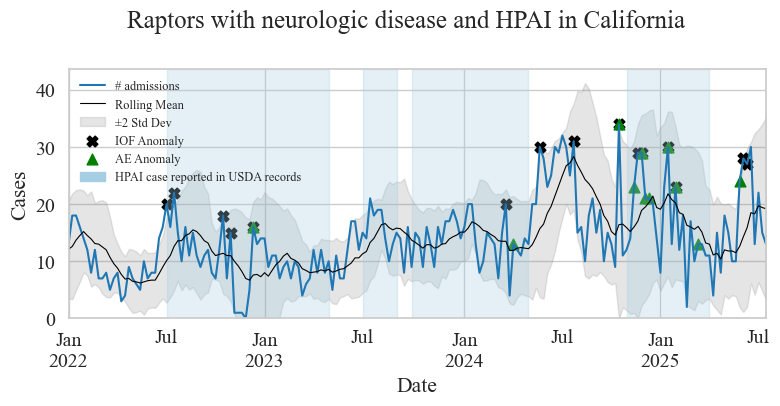

NameError: name 'geocoded_cases_dict' is not defined

In [21]:
%%time
an.plot_multiple_anomaly_timelines(
    filenames=['C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/raptors-with-neurologic-disease-in-california', 
               ],
    window_size=10,
    sigma=2,
    grey_periods=[('2022-07-01', '2023-04-30'), ('2023-07-01', '2023-08-31'),  ('2023-10-01', '2024-04-30'), ('2024-11-01', '2025-03-31')],
    disease_labels=['HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records'],
    plot_top_axis=False, 
    plot_start_date="2022-01-01",
    save=True,
    save_path = "Raptors with neurologic disease and HPAI in California.png"
)

In [3]:
%%time
an.plot_multiple_anomaly_timelines(
    filenames=['C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/raptors-with-neurologic-disease-in-california', 
               ],
    window_size=10,
    sigma=2,
    grey_periods=[('2022-07-01', '2023-04-30'), ('2023-07-01', '2023-08-31'),  ('2023-10-01', '2024-04-30'), ('2024-11-01', '2025-03-31')],
    disease_labels=['HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records'],
    plot_top_axis=False, 
    plot_start_date="2022-01-01",
    save=True,
    save_path = "Raptors with neurologic disease and HPAI in California.png", 
    plot_map=True,
    geocoded_cases_dict=None,  # not used anymore
    state_shapes=state_shapes,
    all_cases_df=your_dataframe_with_lat_long_and_state
)

NameError: name 'an' is not defined

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Fleiss' Kappa: 0.273
Cohen's Kappa (IOF vs AE): 0.522
C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/shorebirds-with-neurologic-disease-in-california date range: 2015-01-11 00:00:00 to 2025-07-20 00:00:00
Saved to: Shorebirds with neurologic disease and HPAI in California.png


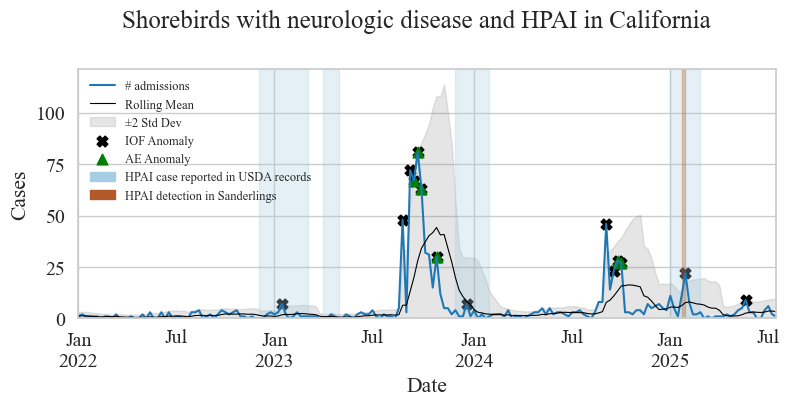

CPU times: total: 27.3 s
Wall time: 26.6 s


In [37]:
%%time
plot_multiple_anomaly_timelines(
    filenames=['C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/shorebirds-with-neurologic-disease-in-california', 
               ],
    window_size=10,
    sigma=2,
    grey_periods=[('2022-12-01', '2023-02-28'), ('2023-04-01', '2023-04-30'), ('2023-12-01', '2024-01-31'),  ('2025-01-01', '2025-02-28'), 
    ('2025-01-25', '2025-02-01')],
    disease_labels=["HPAI case reported in USDA records", "HPAI case reported in USDA records","HPAI case reported in USDA records","HPAI case reported in USDA records",'HPAI detection in Sanderlings'],
    plot_top_axis=False, 
    plot_start_date="2022-01-01",
    save=True,
    save_path = "Shorebirds with neurologic disease and HPAI in California.png"
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fleiss' Kappa: 0.316
Cohen's Kappa (IOF vs AE): 0.472
C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/shorebirds-with-neurologic-disease-in-california date range: 2015-01-11 00:00:00 to 2025-07-20 00:00:00
Saved to: Shorebirds with neurologic disease and HPAI in California.png


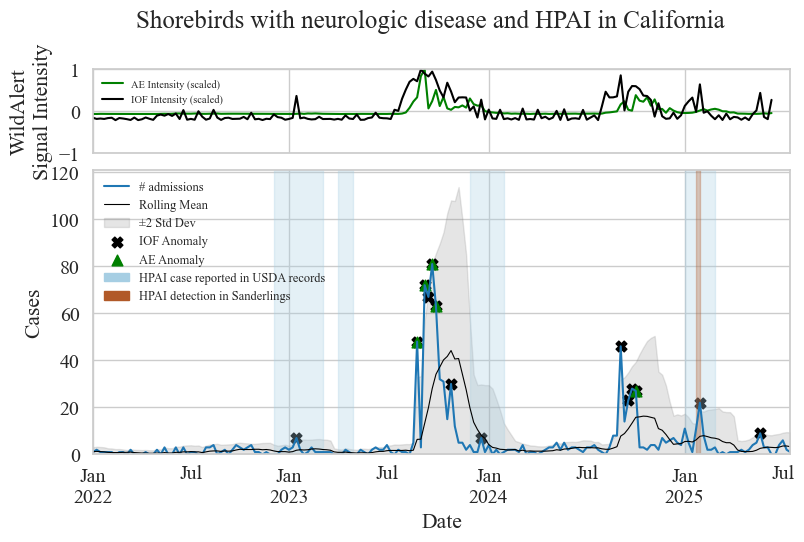

CPU times: total: 27.6 s
Wall time: 30 s


In [38]:
%%time
plot_multiple_anomaly_timelines(
    filenames=['C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/shorebirds-with-neurologic-disease-in-california', 
               ],
    window_size=10,
    sigma=2,
    grey_periods=[('2022-12-01', '2023-02-28'), ('2023-04-01', '2023-04-30'), ('2023-12-01', '2024-01-31'),  ('2025-01-01', '2025-02-28'), 
    ('2025-01-25', '2025-02-01')],
    disease_labels=["HPAI case reported in USDA records", "HPAI case reported in USDA records","HPAI case reported in USDA records","HPAI case reported in USDA records",'HPAI detection in Sanderlings'],
    plot_top_axis=True, 
    plot_start_date="2022-01-01",
    save=True,
    save_path = "Shorebirds with neurologic disease and HPAI in California.png"
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Fleiss' Kappa: 0.210
Cohen's Kappa (IOF vs AE): 0.245
C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/raptors-with-neurologic-disease-in-california date range: 2015-01-04 00:00:00 to 2025-07-20 00:00:00
Saved to: Raptors with neurologic disease and HPAI in California.png


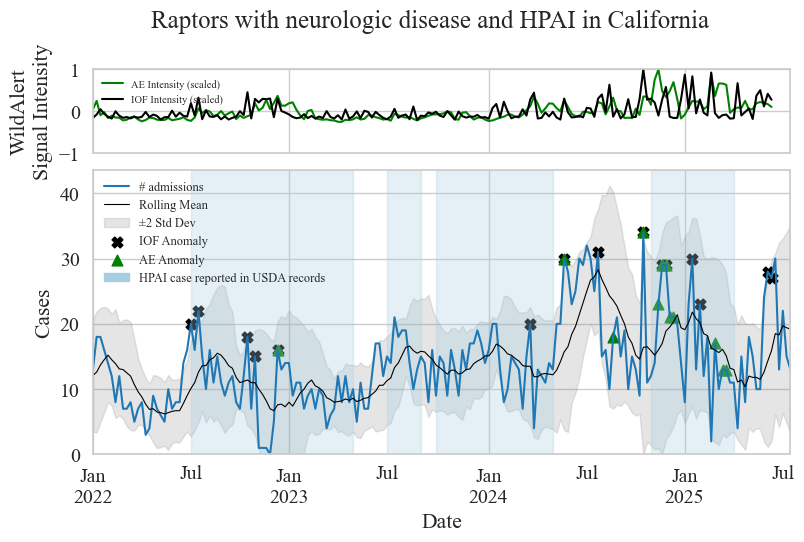

CPU times: total: 33 s
Wall time: 33.5 s


In [39]:
%%time
plot_multiple_anomaly_timelines(
    filenames=['C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/paper_exports/endemic/raptors-with-neurologic-disease-in-california', 
               ],
    window_size=10,
    sigma=2,
    grey_periods=[('2022-07-01', '2023-04-30'), ('2023-07-01', '2023-08-31'),  ('2023-10-01', '2024-04-30'), ('2024-11-01', '2025-03-31')],
    disease_labels=['HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records', 'HPAI case reported in USDA records'],
    plot_top_axis=True, 
    plot_start_date="2022-01-01",
    save=True,
    save_path = "Raptors with neurologic disease and HPAI in California.png"
)